# Week 7 — Knowledge Distillation via Chain-of-Thought

**Idea:** Use a cheap OpenRouter *teacher* model to annotate product descriptions with brief pricing reasoning.  
Fine-tune a tiny *student* model (`Qwen2.5-0.5B`) on these CoT-enriched examples — it learns not just *what* prices are, but *why*.

**Three-tier comparison:**

| Tier | Model | Training |
|------|-------|----------|
| Baseline | `llama-3.1-8b-instruct` via OpenRouter | Zero-shot |
| Student (CoT) | `Qwen2.5-0.5B` fine-tuned | Reasoning + price targets |

**Steps:**
1. Load 300 items → annotate with teacher → push CoT dataset to HuggingFace
2. Baseline eval: zero-shot teacher on 100 test items
3. Fine-tune student in Google Colab (link below)
4. Compare all two tiers

In [1]:
import os, re, sys, pathlib
from concurrent.futures import ThreadPoolExecutor
from dotenv import load_dotenv
from huggingface_hub import login
from openai import OpenAI
from datasets import DatasetDict, Dataset
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

sys.path.insert(0, str(pathlib.Path().resolve().parents[1]))
from pricer.items import Item
from helper import (
    OPENROUTER_URL, OPENROUTER_API_KEY,
    TEACHER_MODEL, STUDENT_BASE_MODEL, COT_RESPONSE_TEMPLATE,
    annotate, make_cot_prompt, make_cot_completion,
    make_standard_prompt, zero_shot_predict,
)

In [2]:
load_dotenv(override=True)
login(os.environ["HF_TOKEN"], add_to_git_credential=True)

HF_USER    = "ai-amitb"   # ← replace with your HuggingFace username
DATASET_ID = f"{HF_USER}/items-cot-prompts"

TRAIN_SIZE = 100
VAL_SIZE   = 20
TEST_SIZE  = 30

client = OpenAI(base_url=OPENROUTER_URL, api_key=OPENROUTER_API_KEY)
print(f"Teacher : {TEACHER_MODEL}")
print(f"Student : {STUDENT_BASE_MODEL}")
print(f"Dataset : {DATASET_ID}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Teacher : meta-llama/llama-3.1-8b-instruct
Student : Qwen/Qwen2.5-0.5B
Dataset : ai-amitb/items-cot-prompts


## Step 1 — Load & Annotate Data

In [3]:
train, val, test = Item.from_hub("ai-amitb/items_lite")
train, val, test = train[:TRAIN_SIZE], val[:VAL_SIZE], test[:TEST_SIZE]
print(f"Loaded: {len(train)} train | {len(val)} val | {len(test)} test items")

Loaded: 100 train | 20 val | 30 test items


In [4]:
item = train[5]
print(f"Title:    {item.title}")
print(f"Category: {item.category}")
print(f"Price:    ${item.price:.2f}\n")
print(item.summary)

Title:    Maxorber Shock Struts, Front Struts Shock Absorbers Kit Compatible with 2007 2008 2009 2010 2011 for Honda CR-V 341492 72497 Set of 2
Category: Automotive
Price:    $89.99

Title: Maxorber Front Shock Absorber Kit for 2007‑2011 Honda CR‑V  
Category: Automotive Parts  
Brand: Maxorber  
Description: A durable pair of front shock absorbers designed for Honda CR‑V models 2007‑2011.  
Details: Features precise mounting, anti‑leak construction, and a 12‑month warranty for enhanced performance and safety.


In [6]:
# Quick sanity check — run this on a single item before the full batch
# It will print the raw API response so you can see exactly what the model returns
# from prompts.prompts import TEACHER_SYSTEM
# from helper import teacher_user

# resp = client.chat.completions.create(
#     model=TEACHER_MODEL,
#     messages=[
#         {"role": "system", "content": TEACHER_SYSTEM},
#         {"role": "user",   "content": teacher_user(train[0].summary)},
#     ],
#     temperature=0.3,
#     max_tokens=200,
# )
# raw = resp.choices[0].message.content.strip()
# print("RAW RESPONSE:\n", raw)
# print("\nEXTRACTED:", annotate(train[0], client))

In [7]:
def _annotate_one(item):
    reasoning, price = annotate(item, client)
    return item, reasoning


def _build_rows(items, include_cot=True):
    with ThreadPoolExecutor(max_workers=5) as ex:
        results = list(tqdm(ex.map(_annotate_one, items), total=len(items)))
    rows = []
    for item, reasoning in results:
        if include_cot and not reasoning:
            continue
        rows.append({
            "prompt":     make_cot_prompt(item.summary) if include_cot else make_standard_prompt(item.summary),
            "completion": make_cot_completion(reasoning, item.price) if include_cot else str(item.price),
            "reasoning":  reasoning or "",
            "price":      item.price,
            "title":      item.title,
            "category":   item.category,
        })
    return rows


print("Annotating train…")
cot_train = _build_rows(train)
print(f"→ {len(cot_train)} / {len(train)} annotated")

print("Annotating val…")
cot_val = _build_rows(val)
print(f"→ {len(cot_val)} / {len(val)} annotated")

cot_test = _build_rows(test, include_cot=False)
print(f"Test   : {len(cot_test)} rows (standard format, no annotation)")

Annotating train…


  0%|          | 0/100 [00:00<?, ?it/s]

→ 100 / 100 annotated
Annotating val…


  0%|          | 0/20 [00:00<?, ?it/s]

→ 20 / 20 annotated


  0%|          | 0/30 [00:00<?, ?it/s]

Test   : 30 rows (standard format, no annotation)


In [8]:
row = cot_train[5]
print("── PROMPT ──")
print(row["prompt"])
print("── COMPLETION ──")
print(row["completion"])

── PROMPT ──
What does this cost to the nearest dollar?

Title: Maxorber Front Shock Absorber Kit for 2007‑2011 Honda CR‑V  
Category: Automotive Parts  
Brand: Maxorber  
Description: A durable pair of front shock absorbers designed for Honda CR‑V models 2007‑2011.  
Details: Features precise mounting, anti‑leak construction, and a 12‑month warranty for enhanced performance and safety.


── COMPLETION ──
Reasoning: Considering the product is an automotive part, specifically a shock absorber kit, which is a critical component for vehicle safety and performance. The Maxorber brand suggests a mid-to-high quality tier, as it's a specific brand mentioned, implying a certain level of expertise and reputation. Additionally, the 12-month warranty and anti-leak construction features suggest a premium offering.

Price is $90.00


## Step 2 — Push CoT Dataset to HuggingFace

In [9]:
DATASET_ID

'ai-amitb/items-cot-prompts'

In [10]:
ds = DatasetDict({
    "train":      Dataset.from_list(cot_train),
    "validation": Dataset.from_list(cot_val),
    "test":       Dataset.from_list(cot_test),
})
ds.push_to_hub(DATASET_ID)
print(f"Dataset live at: https://huggingface.co/datasets/{DATASET_ID}")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Dataset live at: https://huggingface.co/datasets/ai-amitb/items-cot-prompts


## Step 3 — Baseline Evaluation (Zero-Shot Teacher)

Measure the teacher model's zero-shot accuracy before any fine-tuning.  
This is the ceiling we want to approach with the much smaller student.

In [11]:
errors, guesses, truths = [], [], []

for item in tqdm(test, desc=f"Zero-shot [{TEACHER_MODEL}]"):
    pred  = zero_shot_predict(item.summary, client)
    m     = re.search(r"\d+(?:\.\d+)?", pred.replace(",", ""))
    guess = float(m.group()) if m else 0.0
    errors.append(abs(guess - item.price))
    guesses.append(guess)
    truths.append(item.price)

avg_error = sum(errors) / len(errors)
print(f"\n{TEACHER_MODEL}")
print(f"Avg absolute error: ${avg_error:,.2f}  (n={len(errors)})")

Zero-shot [meta-llama/llama-3.1-8b-instruct]:   0%|          | 0/30 [00:00<?, ?it/s]


meta-llama/llama-3.1-8b-instruct
Avg absolute error: $172.60  (n=30)


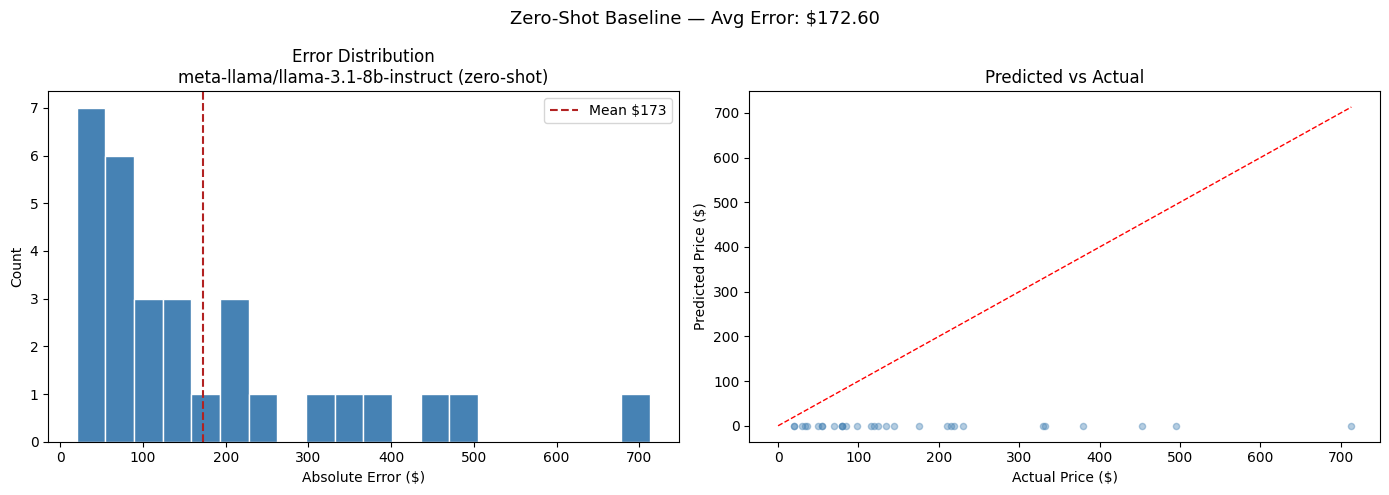

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(errors, bins=20, color="steelblue", edgecolor="white")
ax1.axvline(avg_error, color="firebrick", linestyle="--", label=f"Mean ${avg_error:.0f}")
ax1.set_title(f"Error Distribution\n{TEACHER_MODEL} (zero-shot)")
ax1.set_xlabel("Absolute Error ($)")
ax1.set_ylabel("Count")
ax1.legend()

ax2.scatter(truths, guesses, alpha=0.4, color="steelblue", s=20)
ax2.plot([0, max(truths)], [0, max(truths)], "r--", linewidth=1)
ax2.set_title("Predicted vs Actual")
ax2.set_xlabel("Actual Price ($)")
ax2.set_ylabel("Predicted Price ($)")

plt.suptitle(f"Zero-Shot Baseline — Avg Error: ${avg_error:.2f}", fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
from sklearn.metrics import mean_squared_error, r2_score

base_mse = mean_squared_error(truths, guesses)
base_r2  = r2_score(truths, guesses) * 100

green  = sum(1 for e, t in zip(errors, truths) if e < 40 or e / t < 0.2)
orange = sum(1 for e, t in zip(errors, truths) if (40 <= e < 80 or 0.2 <= e / t < 0.4) and not (e < 40 or e / t < 0.2))
red    = len(errors) - green - orange

print(f"Avg Error : ${avg_error:,.2f}")
print(f"MSE       : {base_mse:,.0f}")
print(f"R²        : {base_r2:.1f}%")
print(f"\nGreen  (<$40 or <20%) : {green:>3} ({green/len(errors):.0%})")
print(f"Orange (<$80 or <40%) : {orange:>3} ({orange/len(errors):.0%})")
print(f"Red                   : {red:>3} ({red/len(errors):.0%})")

# ── Copy these three values into the Colab comparison cell ──
print(f"\nBASELINE = ({avg_error:.2f}, {base_mse:.0f}, {base_r2:.1f})")

Avg Error : $172.60
MSE       : 55,934
R²        : -114.0%

Green  (<$40 or <20%) :   5 (17%)
Orange (<$80 or <40%) :   7 (23%)
Red                   :  18 (60%)


## Step 4 — Fine-Tune the Student (Google Colab)

Run the cells below in a Colab notebook (T4 GPU, free tier is enough).  
The CoT dataset is already on HuggingFace from Step 2.

`DataCollatorForCompletionOnlyLM` masks the prompt so the model only trains on the completion — the reasoning trace + final price — starting from `"Reasoning: "`.

In [ ]:
%pip install -q transformers peft trl bitsandbytes accelerate datasets huggingface_hub scikit-learn

In [ ]:
import os, re, torch
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, PeftModel
from trl import SFTTrainer, SFTConfig
from sklearn.metrics import mean_squared_error, r2_score

load_dotenv()
login(os.environ["HF_TOKEN"], add_to_git_credential=True)

In [15]:
HF_USER    = "ai-amitb"               # ← your HuggingFace username
BASE_MODEL = "Qwen/Qwen2.5-0.5B"
DATASET_ID = f"{HF_USER}/items-cot-prompts"
HUB_MODEL  = f"{HF_USER}/cot-pricer"

print(f"Base  : {BASE_MODEL}")
print(f"Data  : {DATASET_ID}")
print(f"Output: {HUB_MODEL}")

Base  : Qwen/Qwen2.5-0.5B
Data  : ai-amitb/items-cot-prompts
Output: ai-amitb/cot-pricer


In [ ]:
ds = load_dataset(DATASET_ID)

def to_text(ex):
    return {"text": ex["prompt"] + ex["completion"]}

train_data = ds["train"].map(to_text)
val_data   = ds["validation"].map(to_text)
test_data  = ds["test"]
print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")
print("\nSample completion:\n", train_data[0]["text"][-300:])

In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,   # float16 for T4 compatibility
)

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    device_map="auto",
)
model.config.use_cache = False
print(f"Loaded {BASE_MODEL}  |  device: {next(model.parameters()).device}")

In [ ]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

sft_config = SFTConfig(
    output_dir="cot-pricer",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,
    learning_rate=2e-4,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    dataset_text_field="text",
    fp16=False,
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none",
    push_to_hub=True,
    hub_model_id=HUB_MODEL,
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_data,
    eval_dataset=val_data,
    peft_config=lora_config,
)

trainer.train()
trainer.push_to_hub()
print(f"Model at: https://huggingface.co/{HUB_MODEL}")

### Evaluate Fine-Tuned Student

In [ ]:
base_eval = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL, quantization_config=bnb_config, device_map="auto"
)
model_ft = PeftModel.from_pretrained(base_eval, HUB_MODEL)
model_ft.eval()


def predict(prompt: str) -> float:
    inputs = tokenizer(prompt, return_tensors="pt").to(model_ft.device)
    with torch.no_grad():
        out = model_ft.generate(**inputs, max_new_tokens=20, do_sample=False)
    full_text = tokenizer.decode(out[0], skip_special_tokens=True)
    m = re.search(r"Price is \$(\d+(?:\.\d+)?)", full_text)
    if m:
        return float(m.group(1))
    # fallback: grab the first number in the newly generated tokens
    new_text = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    m = re.search(r"\d+(?:\.\d+)?", new_text.replace(",", ""))
    return float(m.group()) if m else 0.0


errors, guesses, truths = [], [], []
for row in test_data:
    guess = predict(row["prompt"])
    truth = float(row["price"])
    errors.append(abs(guess - truth))
    guesses.append(guess)
    truths.append(truth)

avg_error = sum(errors) / len(errors)
mse       = mean_squared_error(truths, guesses)
r2        = r2_score(truths, guesses) * 100
green     = sum(1 for e, t in zip(errors, truths) if e < 40 or e / t < 0.2)
orange    = sum(1 for e, t in zip(errors, truths) if (40 <= e < 80 or 0.2 <= e / t < 0.4) and not (e < 40 or e / t < 0.2))
red       = len(errors) - green - orange

print(f"Fine-tuned {BASE_MODEL} (CoT distillation)")
print(f"Avg Error : ${avg_error:,.2f}")
print(f"MSE       : {mse:,.0f}")
print(f"R²        : {r2:.1f}%")
print(f"\nGreen  (<$40 or <20%) : {green:>3} ({green/len(errors):.0%})")
print(f"Orange (<$80 or <40%) : {orange:>3} ({orange/len(errors):.0%})")
print(f"Red                   : {red:>3} ({red/len(errors):.0%})")

### Results — Three-Tier Comparison

Paste the `BASELINE = (...)` line printed at the end of Step 3 into the cell below.

In [17]:
# ── Paste your Step 3 output here ──
BASELINE = (172.60, 99999, -114.0)   # (avg_error, mse, r2) ← replace with your values

# ── Paste your Step 4 output here (from colab training) ──
results = {
    f"Zero-shot {TEACHER_MODEL}":         BASELINE,
    f"Fine-tuned {BASE_MODEL} (CoT)":     (122.57, 34156, -30.7),
}

print(f"\n{'Model':<45} {'Avg Error':>12} {'MSE':>12} {'R²':>8}")
print("─" * 81)
for name, (ae, m, r) in results.items():
    print(f"{name:<45} ${ae:>10,.2f} {m:>12,.0f} {r:>7.1f}%")


Model                                            Avg Error          MSE       R²
─────────────────────────────────────────────────────────────────────────────────
Zero-shot meta-llama/llama-3.1-8b-instruct    $    172.60       99,999  -114.0%
Fine-tuned Qwen/Qwen2.5-0.5B (CoT)            $    122.57       34,156   -30.7%


## Colab Notebook link with finetuned qwen model and evaluations
https://colab.research.google.com/drive/17hvdX0Rclw6QhDiAd6uXoj9W1rriOk_O?usp=sharing